research question

One clear two-sample research question
Is the proportion of current cigarette use different between male and female students?

variable definition

In [134]:
variable_definition = pd.DataFrame({
    "Type": ["Group Variable", "Response Variable"],
    "Variable": ["WhatIsYourSex", "CurrentCigaretteUse"],
    "Meaning": [
        "Separates students into Male and Female groups",
        "Indicates whether a student currently uses cigarettes"
    ],
    "Role in Analysis": [
        "Defines the two groups being compared",
        "Binary outcome used to calculate current cigarette use proportion"
    ]
})

variable_definition

,Type,Variable,Meaning,Role in Analysis
0,Group Variable,WhatIsYourSex,Separates students into Male and Female groups,Defines the two groups being compared
1,Response Variable,CurrentCigaretteUse,Indicates whether a student currently uses cig...,Binary outcome used to calculate current cigar...


appropriate data cleaning and recoding

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import confint_proportions_2indep

讀取資料

In [105]:
import pandas as pd

df = pd.read_csv("YRBS_2007.csv")

df.head()

,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,...,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
0,7.0,4.0,2.0,2.0,1.0,C,NaN,NaN,2.0,1.0,...,3.0,2.0,1.0,1.0,5.0,3.0,NaN,1.5104,101,11030
1,5.0,7.0,2.0,2.0,2.0,E,1.70,68.04,4.0,4.0,...,2.0,3.0,1.0,5.0,4.0,3.0,66.531824,1.8559,101,11030
2,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,5.0,3.0,...,2.0,3.0,2.0,1.0,1.0,1.0,NaN,1.8559,101,11030
3,7.0,1.0,1.0,1.0,1.0,A,1.63,79.38,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,98.174319,1.3264,101,11030
4,7.0,1.0,1.0,5.0,1.0,B,NaN,NaN,6.0,5.0,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.3264,101,11030


留性別跟目前抽菸

In [107]:
df2 = df[['WhatIsYourSex', 'CurrentCigaretteUse']].copy()

df2.head()

,WhatIsYourSex,CurrentCigaretteUse
0,2.0,7.0
1,2.0,NaN
2,2.0,NaN
3,1.0,1.0
4,1.0,1.0


In [109]:
print(df2['WhatIsYourSex'].value_counts(dropna=False))
print(df2['CurrentCigaretteUse'].value_counts(dropna=False))

WhatIsYourSex
1.0    7036
2.0    6992
NaN      13
Name: count, dtype: int64
CurrentCigaretteUse
1.0    10734
2.0      753
NaN      718
7.0      687
3.0      375
5.0      295
4.0      250
6.0      229
Name: count, dtype: int64


刪掉缺失值

In [111]:
df2 = df2.dropna()

df2.shape

(13312, 2)

把原本的數字改成文字

In [113]:
df2['Sex_Recode'] = df2['WhatIsYourSex'].map({
    1: 'Male',
    2: 'Female'
})

df2[['WhatIsYourSex', 'Sex_Recode']].head()

,WhatIsYourSex,Sex_Recode
0,2.0,Female
3,1.0,Male
4,1.0,Male
5,1.0,Male
6,1.0,Male


抽菸變數改成 0 / 1

In [115]:
df2['CurrentCigaretteUse_Recode'] = np.where(
    df2['CurrentCigaretteUse'] == 1,
    0,
    1
)

df2[['CurrentCigaretteUse', 'CurrentCigaretteUse_Recode']].head()

,CurrentCigaretteUse,CurrentCigaretteUse_Recode
0,7.0,1
3,1.0,0
4,1.0,0
5,1.0,0
6,1.0,0


刪掉性別不是 1 或 2的

In [117]:
df2 = df2.dropna(subset=['Sex_Recode'])

df2['Sex_Recode'].value_counts()

Sex_Recode
Male      6740
Female    6572
Name: count, dtype: int64

summary table

In [119]:
summary = df2.groupby('Sex_Recode')['CurrentCigaretteUse_Recode'].agg(
    Sample_Size='count',
    Current_Smokers='sum',
    Proportion='mean'
)

summary

,Sample_Size,Current_Smokers,Proportion
Sex_Recode,,,
Female,6572,1418,0.215764
Male,6740,1167,0.173145


In [121]:
summary['Percentage'] = summary['Proportion'] * 100

summary

,Sample_Size,Current_Smokers,Proportion,Percentage
Sex_Recode,,,,
Female,6572,1418,0.215764,21.576385
Male,6740,1167,0.173145,17.314540


Current Cigarette Use by Gender的圖

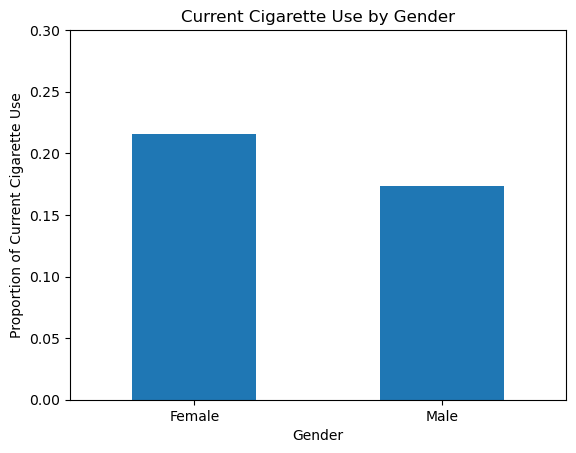

In [123]:
summary['Proportion'].plot(kind='bar')

plt.title('Current Cigarette Use by Gender')
plt.xlabel('Gender')
plt.ylabel('Proportion of Current Cigarette Use')
plt.ylim(0, 0.3)
plt.xticks(rotation=0)

plt.show()

two-proportion z-test and p-value

In [125]:
male = df2[df2['Sex_Recode'] == 'Male']
female = df2[df2['Sex_Recode'] == 'Female']

count = [
    male['CurrentCigaretteUse_Recode'].sum(),
    female['CurrentCigaretteUse_Recode'].sum()
]

nobs = [
    len(male),
    len(female)
]

z_stat, p_value = proportions_ztest(count, nobs)

print("Male smokers:", count[0])
print("Female smokers:", count[1])
print("Male sample size:", nobs[0])
print("Female sample size:", nobs[1])
print("z statistic:", z_stat)
print("p-value:", p_value)

Male smokers: 1167
Female smokers: 1418
Male sample size: 6740
Female sample size: 6572
z statistic: -6.214820309970149
p-value: 5.138341623910967e-10


算 difference(男生抽菸比例 − 女生抽菸比例)

In [148]:
p_male = count[0] / nobs[0]
p_female = count[1] / nobs[1]

difference = p_male - p_female

print("Male proportion:", p_male)
print("Female proportion:", p_female)
print("Difference male - female:", difference)

Male proportion: 0.1731454005934718
Female proportion: 0.21576384662203288
Difference male - female: -0.042618446028561074


In [ ]:
95% confidence interval

In [136]:
ci_low, ci_high = confint_proportions_2indep(
    count1=count[0],
    nobs1=nobs[0],
    count2=count[1],
    nobs2=nobs[1],
    method='wald'
)

print("95% CI for male - female:")
print(ci_low, ci_high)

#我們估計男生抽菸比例大約比女生低：2.9% ～ 5.6% 全部負的代表：幾乎可以確定有差異

95% CI for male - female:
-0.05605361482170604 -0.029183277235416107


confidence interval的圖

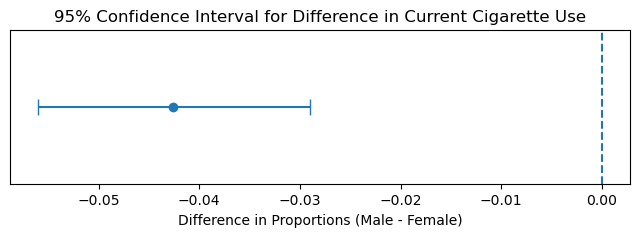

In [146]:
import matplotlib.pyplot as plt

difference = -0.0426
ci_low = -0.056
ci_high = -0.029

plt.figure(figsize=(8,2))

plt.errorbar(
    x=difference,
    y=0,
    xerr=[[difference - ci_low], [ci_high - difference]],
    fmt='o',
    capsize=6
)

plt.axvline(x=0, linestyle='--')

plt.yticks([])

plt.xlabel('Difference in Proportions (Male - Female)')
plt.title('95% Confidence Interval for Difference in Current Cigarette Use')

plt.show()

Hypothesis test and conclusion

In [138]:
print("Hypothesis Test and Conclusion")
print()
print("H0: p_male = p_female")
print("The proportion of current cigarette use is the same for male and female students.")
print()
print("H1: p_male != p_female")
print("The proportion of current cigarette use is different between male and female students.")
print()
print(f"z statistic = {z_stat:.3f}")
print(f"p-value = {p_value:.2e}")
print()
print("Since the p-value is less than 0.05, we reject the null hypothesis.")
print("There is sufficient evidence to conclude that current cigarette use differs between male and female students.")
print("Female students had a higher proportion of current cigarette use than male students.")

Hypothesis Test and Conclusion

H0: p_male = p_female
The proportion of current cigarette use is the same for male and female students.

H1: p_male != p_female
The proportion of current cigarette use is different between male and female students.

z statistic = -6.215
p-value = 5.14e-10

Since the p-value is less than 0.05, we reject the null hypothesis.
There is sufficient evidence to conclude that current cigarette use differs between male and female students.
Female students had a higher proportion of current cigarette use than male students.


Summary and Conclusion

In [144]:
print("Summary:")
print(f"Male proportion: {p_male:.3f}")
print(f"Female proportion: {p_female:.3f}")
print(f"Difference (male - female): {difference:.4f}")
print(f"z statistic: {z_stat:.3f}")
print(f"p-value: {p_value:.2e}")
print(f"95% CI: ({ci_low:.3f}, {ci_high:.3f})")
print()

if p_value < 0.05:
    print("Conclusion: Reject H0. There is sufficient evidence that the proportions are different.")
else:
    print("Conclusion: Fail to reject H0. There is not sufficient evidence that the proportions are different.")
    
#我們原本假設男女抽菸比例沒有差。但現在資料顯示：女生抽菸比例明顯比較高，而且這個差異大到不像隨機造成。因此我們拒絕「沒差」這個假設，認為男女抽菸比例真的有顯著差異。

Summary:
Male proportion: 0.173
Female proportion: 0.216
Difference (male - female): -0.0426
z statistic: -6.215
p-value: 5.14e-10
95% CI: (-0.056, -0.029)

Conclusion: Reject H0. There is sufficient evidence that the proportions are different.
